# Day 2 — DBSCAN & Hierarchical Clustering

##   Load and Understand the Dataset

In this lab, DBSCAN and Hierarchical Clustering will be applied to the same Mall Customers dataset used in Day 1.

The goal is to compare different clustering methods and understand their strengths and limitations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

In [4]:
eps=0.5
min_samples=5

## DBSCAN Clustering

DBSCAN is a density-based clustering algorithm. Unlike K-Means, it does not require the number of clusters to be specified in advance.

The algorithm uses two main parameters:

- eps: the maximum distance between neighboring points.
- min_samples: the minimum number of points required to form a dense region.

Points that do not belong to any dense region are labeled as noise with the value -1.

In [5]:
from sklearn.cluster import DBSCAN

db = DBSCAN(
    eps=0.5,
    min_samples=5
)

db_labels = db.fit_predict(X_scaled)

db_labels[:20]

array([-1,  0, -1,  0, -1,  0, -1, -1, -1,  0, -1, -1, -1,  0, -1,  0,  1,
        0, -1, -1])

In [6]:
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)

n_noise = np.sum(db_labels == -1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 6
Number of noise points: 60


In [7]:
df["DBSCAN_Cluster"] = db_labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),DBSCAN_Cluster
0,1,Male,19,15,39,-1
1,2,Male,21,15,81,0
2,3,Female,20,16,6,-1
3,4,Female,23,16,77,0
4,5,Female,31,17,40,-1


In [8]:
df["DBSCAN_Cluster"].value_counts().sort_index()

DBSCAN_Cluster
-1    60
 0    17
 1     5
 2    51
 3    28
 4    32
 5     7
Name: count, dtype: int64

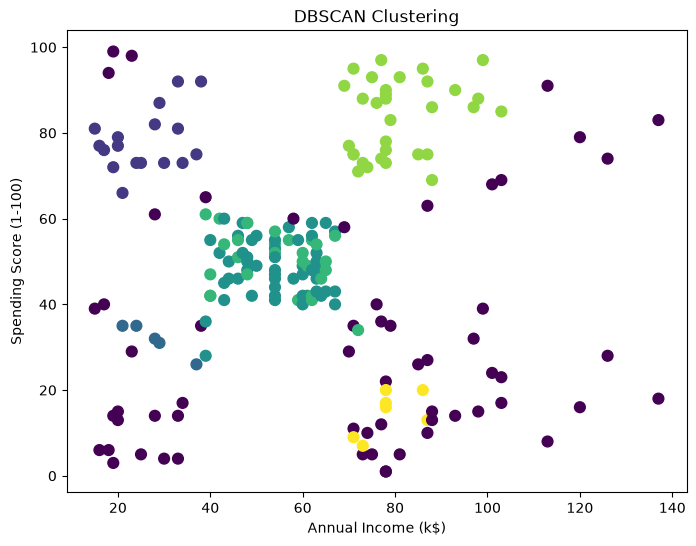

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=db_labels,
    s=60
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering")

plt.show()

##  Hierarchical Clustering

Hierarchical Clustering builds a hierarchy of clusters by repeatedly merging the closest groups of data points.

The resulting hierarchy is visualized using a dendrogram. The dendrogram allows us to observe how clusters are merged at different distance levels and choose an appropriate cut to determine the final number of clusters.

In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method="ward")

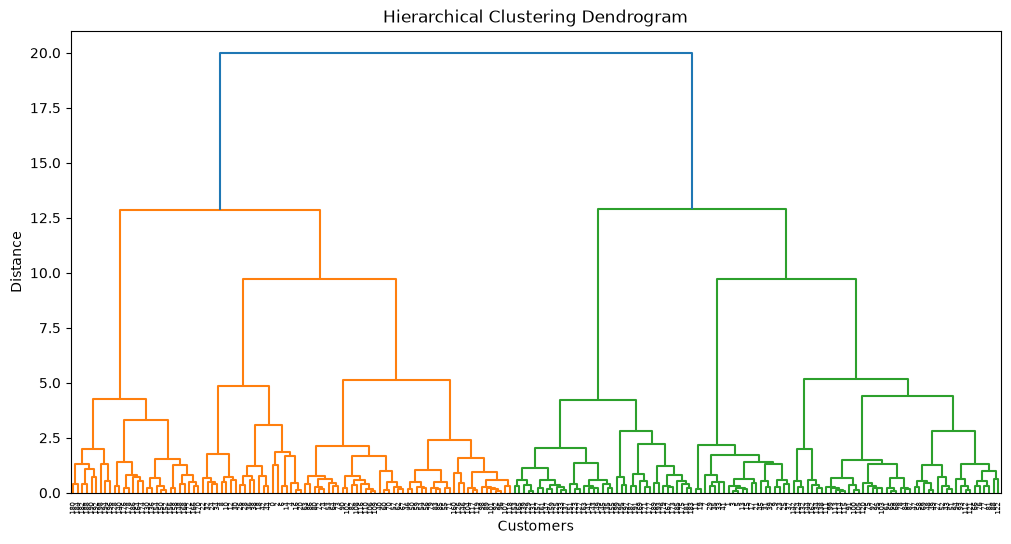

In [12]:
plt.figure(figsize=(12, 6))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

## Choosing the Cut Height

The dendrogram shows a large increase in linkage distance near 20. Before this large jump, the main branches are separated at a distance of approximately 12.

A cut height of around 12 was selected because it preserves the main cluster structure before the large merge. This results in four distinct clusters.

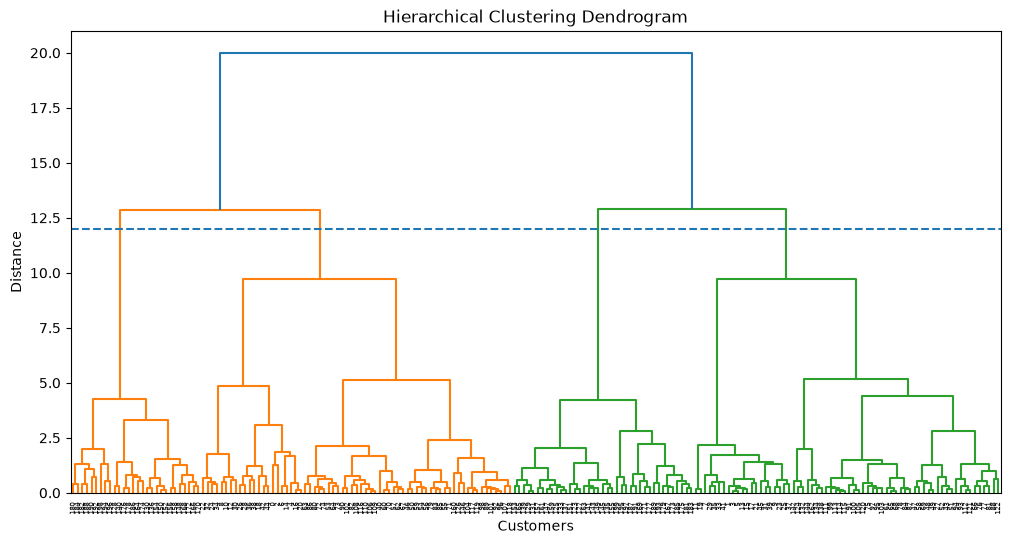

In [13]:
plt.figure(figsize=(12, 6))

dendrogram(Z)

plt.axhline(y=12, linestyle="--")

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

In [14]:
from scipy.cluster.hierarchy import fcluster

hier_labels = fcluster(
    Z,
    t=12,
    criterion="distance"
)

hier_labels[:20]

array([2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4],
      dtype=int32)

In [15]:
n_hier_clusters = len(np.unique(hier_labels))

print("Number of hierarchical clusters:", n_hier_clusters)

Number of hierarchical clusters: 4


In [16]:
df["Hierarchical_Cluster"] = hier_labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),DBSCAN_Cluster,Hierarchical_Cluster
0,1,Male,19,15,39,-1,2
1,2,Male,21,15,81,0,4
2,3,Female,20,16,6,-1,2
3,4,Female,23,16,77,0,4
4,5,Female,31,17,40,-1,2


##  Visualizing Hierarchical Clustering

The hierarchical clustering results are visualized using Annual Income and Spending Score to compare the discovered customer groups with the results from K-Means and DBSCAN.

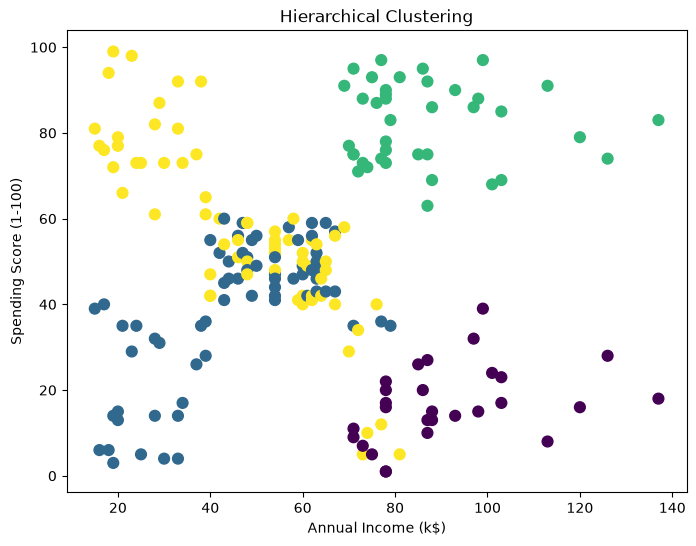

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Hierarchical_Cluster"],
    s=60
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Hierarchical Clustering")

plt.show()

##  Comparing Clustering Methods

K-Means, DBSCAN, and Hierarchical Clustering are compared on the same dataset using Annual Income and Spending Score.

The comparison helps identify how each algorithm groups customers and how DBSCAN handles noise differently from the other methods.

In [19]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

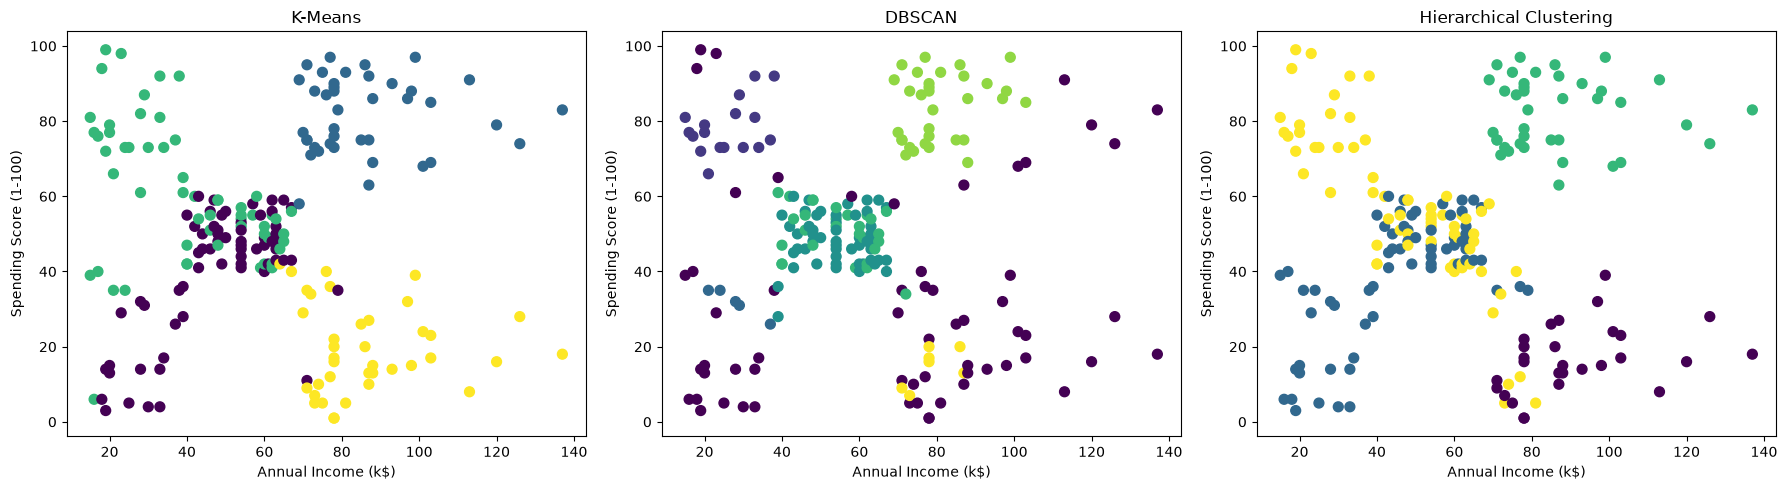

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
axes[0].scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["KMeans_Cluster"],
    s=50
)

axes[0].set_title("K-Means")
axes[0].set_xlabel("Annual Income (k$)")
axes[0].set_ylabel("Spending Score (1-100)")


# DBSCAN
axes[1].scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["DBSCAN_Cluster"],
    s=50
)

axes[1].set_title("DBSCAN")
axes[1].set_xlabel("Annual Income (k$)")
axes[1].set_ylabel("Spending Score (1-100)")


# Hierarchical
axes[2].scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Hierarchical_Cluster"],
    s=50
)

axes[2].set_title("Hierarchical Clustering")
axes[2].set_xlabel("Annual Income (k$)")
axes[2].set_ylabel("Spending Score (1-100)")

plt.tight_layout()
plt.show()

In [21]:
print("K-Means clusters:", df["KMeans_Cluster"].nunique())
print("DBSCAN clusters:", n_clusters)
print("DBSCAN noise points:", n_noise)
print("Hierarchical clusters:", n_hier_clusters)

K-Means clusters: 4
DBSCAN clusters: 6
DBSCAN noise points: 60
Hierarchical clusters: 4
